# Interrogation: the same accumulator, externally-timed readout

Gold & Shadlen (2003, *J Neurosci* 23:632-651) used a design where the *experimenter*, not the subject, decides when evidence stops: motion is shown for a duration `T` drawn independently of the (still-forming, hidden) decision — 100 msec plus a draw from an exponential distribution with mean 300 msec, so `T`'s hazard is close to flat and the subject can't anticipate the cutoff — and the choice is read out from whatever the decision variable's state happens to be at that moment. This is the *interrogation paradigm*: the same stationary-drift accumulation process as `03_ddm.ipynb`, but **no absorbing bound** — the accumulator never stops itself, and there is no boundary-crossing event to key resolution off of.

That difference is exactly what makes this task a much sharper test of capacity limitation than the DDM's. An absorbing bound only ever needs a capacity-limited observer to get two low-dimensional facts right — which side, and roughly when — and `03_ddm.ipynb` §3.4-3.5 showed a handful of well-placed thresholds already nails both. Reading the accumulator out at an unpredictable moment, with no boundary to lock into first, asks for something much closer to the raw continuous position itself. Does capacity still stop mattering by `k~3-4`, or does this task expose something the DDM's own structure was hiding? (Spoiler, derived in full below: it does — capacity needs roughly 3-4x the states here to close the same gap.)

Same three-part shape as the other task notebooks: foundations, single-decision dynamics, testable predictions. General IB theory is in `00_overview.ipynb`; the absorbing-bound machinery this notebook modifies is derived in `03_ddm.ipynb`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "utilities"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from ib_optimal_placement import relevance, optimal_partition_fixed_start, uniform_partition_boundaries_fixed_start, objective_of_boundaries, group_centroids
from interrogation_ib import (
    viewing_duration_density, viewing_duration_grid, fine_reference_interrogation,
    reflecting_ctmc_rates, is_valid_reflecting_chain, reflecting_generator,
    state_distribution_at, interrogation_chain_stats, continuous_interrogation_accuracy,
    simulate_reflecting_chain_path, ib_optimal_chain_interrogation,
)
from intuitions import simulate_ddm_path, quantize_ddm_path

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 12, "axes.labelsize": 12,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.titlesize": 13,
})

NORM_COLOR = "#2b6cb0"
LADDER_COLORS = {2: "#c53030", 4: "#dd6b20", 8: "#d69e2e"}
SHADE_COLOR = "#ebf4ff"

# Same example accumulator as 03_ddm.ipynb (v, s), plus the task's viewing-duration parameters
v, s = 0.6, 1.0
v0 = v
t0_view, tau_view, T_max_view = 0.1, 0.3, 1.5
x_range_view, k0_fine = 8.0, 1500
print(f"accumulator: v={v}, s={s}   viewing duration: t0={t0_view}, tau={tau_view}, T_max={T_max_view}")

accumulator: v=0.6, s=1.0   viewing duration: t0=0.1, tau=0.3, T_max=1.5


## Foundations

Two structural pieces from `03_ddm.ipynb` don't carry over unchanged (full derivation in `utilities/interrogation_ib.py`), and one readout subtlety needs to be gotten right or nothing downstream is trustworthy. All three are derived and checked directly below, not just asserted.

### 1. Occupancy has no fundamental matrix to read it off

With no absorption, "how much time the process spends near `x`" isn't well-defined the way it was for a terminating chain (`03_ddm.ipynb` Part B read it off the fundamental matrix of a fine reference chain). What matters instead is the *marginal distribution of the accumulator's position at whichever time the trial happens to end* — a Gaussian mixture over the task's actual `T` distribution, honest and unknown-sign (the same "the encoder never sees the trial's true sign" convention as `03_ddm.ipynb` Parts C):

```
w(x) = integral over t of f_T(t) * 0.5*[N(x; v0 t, s^2 t) + N(x; -v0 t, s^2 t)] dt
```

`f_T`, the viewing-duration density, is the near-flat-hazard `t0 + Exponential(tau)` distribution (censored at `T_max`) from Gold & Shadlen's actual design. Relevance `q(x) = P(upper | X_t=x)` is untouched — the Girsanov LLR identity behind it has no time dependence, so it's the exact same closed form as `03_ddm.ipynb`.

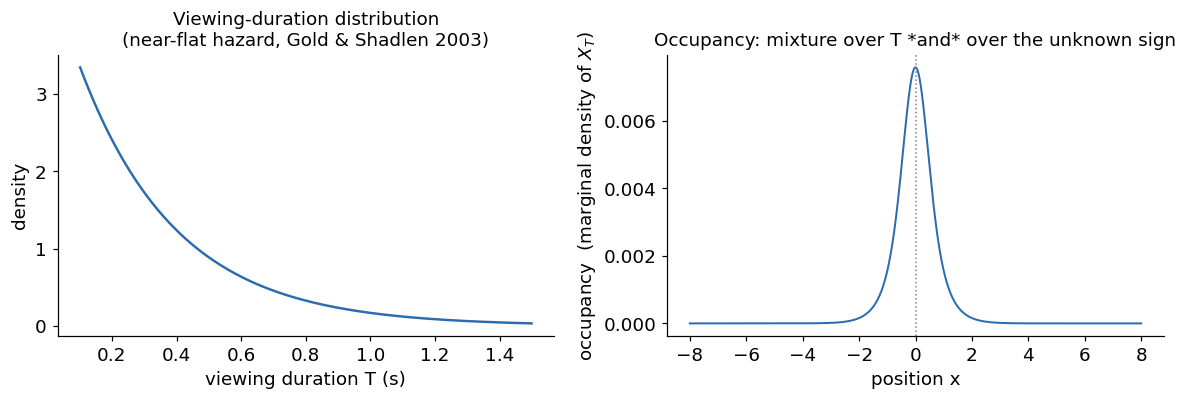

occupancy is symmetric about the start (no absorbing bound to bias it): True
relevance q(x) range: [0.0001, 0.9999] -- same closed-form sigmoid as 03_ddm.ipynb


In [2]:
tgrid, wT = viewing_duration_grid(t0_view, tau_view, T_max_view, n=400)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(tgrid, wT / (tgrid[1] - tgrid[0]), color=NORM_COLOR, lw=1.6)
axes[0].set_xlabel("viewing duration T (s)")
axes[0].set_ylabel("density")
axes[0].set_title("Viewing-duration distribution\n(near-flat hazard, Gold & Shadlen 2003)")

fr = fine_reference_interrogation(k0_fine, v0, s, t0_view, tau_view, T_max_view, x_range_view)
axes[1].plot(fr["x"], fr["w"], color=NORM_COLOR, lw=1.3)
axes[1].axvline(fr["z0_pos"], color="gray", ls=":", lw=1)
axes[1].set_xlabel("position x")
axes[1].set_ylabel("occupancy  (marginal density of $X_T$)")
axes[1].set_title("Occupancy: mixture over T *and* over the unknown sign")
fig.tight_layout()
plt.show()

print(f"occupancy is symmetric about the start (no absorbing bound to bias it): "
      f"{np.allclose(fr['w'], fr['w'][::-1], atol=1e-6)}")
print(f"relevance q(x) range: [{fr['q'].min():.4f}, {fr['q'].max():.4f}] -- same closed-form sigmoid as 03_ddm.ipynb")

### 2. The chain reflects instead of absorbing

A capacity-`k` observer here has `k` *ordinary* states, not `k` interior states flanked by two absorbing labels. The two extreme nodes use a one-sided version of the same Kushner & Dupuis (2001) finite-difference generator used throughout `03_ddm.ipynb` — only the rate pointing back into the domain is kept, instead of routing outward flux to an absorbing state — and the state distribution at a given `T` comes from the exact matrix exponential of that generator (`state_distribution_at`, a transient-distribution problem), not a first-passage one.

In [3]:
k_demo_gen = 6
boundaries_demo, _, _, z0g_demo = optimal_partition_fixed_start(fr["w"], fr["q"], k_demo_gen, fr["z0_index"])
xn_demo = group_centroids(fr["x"], fr["w"], boundaries_demo)
Q_demo = reflecting_generator(xn_demo, v0, s)

print("reflecting generator Q (rows sum to 0 -- no probability leaks out the ends):")
print(np.round(Q_demo, 3))
print(f"\nrow sums: {np.round(Q_demo.sum(1), 8)}")

# state distribution at increasing T -- should spread from a point mass at z0 and never lose mass
for T_check in [0.0, 0.1, 0.5, 1.5]:
    P_T = state_distribution_at(Q_demo, z0g_demo, T_check)
    print(f"T={T_check:4.1f}: P(state)={np.round(P_T, 3)}  (sums to {P_T.sum():.6f})")

reflecting generator Q (rows sum to 0 -- no probability leaks out the ends):
[[ -2.462   2.462   0.      0.      0.      0.   ]
 [  0.778  -3.453   2.675   0.      0.      0.   ]
 [  0.      3.017 -12.716   9.699   0.      0.   ]
 [  0.      0.      8.566 -16.848   8.282   0.   ]
 [  0.      0.      0.      1.753  -3.137   1.384]
 [  0.      0.      0.      0.      0.846  -0.846]]

row sums: [ 0.  0.  0.  0. -0.  0.]
T= 0.0: P(state)=[0. 0. 0. 1. 0. 0.]  (sums to 1.000000)
T= 0.1: P(state)=[0.001 0.048 0.236 0.307 0.374 0.032]  (sums to 1.000000)
T= 0.5: P(state)=[0.021 0.113 0.108 0.112 0.418 0.227]  (sums to 1.000000)
T= 1.5: P(state)=[0.029 0.087 0.069 0.074 0.319 0.423]  (sums to 1.000000)


### 3. A readout subtlety that isn't a footnote

Accuracy has to be scored by where the state ends up relative to the start (a hard, deterministic decision), not by a soft, probability-matching readout `E[q(X_T)]` (mixing choices in proportion to how confident the decoder is). The latter is a strictly worse decision rule, checkable directly: at `v=0.6, s=1, T=1.5`, the deterministic rule reaches the exact continuum ceiling `Phi(v*sqrt(T)/s)`; the soft rule falls well short and — unlike the deterministic rule — never closes that gap even as resolution grows, because averaging in a graded confidence on the *wrong* side still costs accuracy that committing to the more-likely side would not.

In [4]:
v_check, s_check, T_check2 = 0.6, 1.0, 1.5
rng_check = np.random.default_rng(0)
N_check = 2_000_000
sign = rng_check.choice([1, -1], size=N_check)
x_draw = rng_check.normal(sign * v_check * T_check2, s_check * np.sqrt(T_check2))
q_draw = relevance(x_draw, v_check, s_check, 0.0)

soft_acc = np.mean(np.where(sign == 1, q_draw, 1 - q_draw))
det_acc = np.mean((x_draw > 0) == (sign == 1))
ceiling = continuous_interrogation_accuracy(v_check, s_check, [T_check2])[0]

print(f"soft readout  E[q(X_T)]:        {soft_acc:.4f}")
print(f"deterministic sign(X_T):        {det_acc:.4f}")
print(f"continuum ceiling Phi(v*sqrt(T)/s): {ceiling:.4f}")
print("\nThe deterministic rule matches the true ceiling (to simulation noise); the soft rule falls")
print("~8 percentage points short and has no mechanism to close that gap by adding resolution -- it's")
print("scoring a fundamentally worse decision rule, not a noisier version of the right one. Every")
print("accuracy number in this notebook (and 03_ddm.ipynb) uses the deterministic rule.")

soft readout  E[q(X_T)]:        0.6851
deterministic sign(X_T):        0.7690
continuum ceiling Phi(v*sqrt(T)/s): 0.7688

The deterministic rule matches the true ceiling (to simulation noise); the soft rule falls
~8 percentage points short and has no mechanism to close that gap by adding resolution -- it's
scoring a fundamentally worse decision rule, not a noisier version of the right one. Every
accuracy number in this notebook (and 03_ddm.ipynb) uses the deterministic rule.


### Putting it together: does honest placement beat uniform here, and does it stay valid?

Same question `03_ddm.ipynb` Part C asked for the absorbing case, plus a new one: a placement's node spacing (not just its state *count*) determines whether the reflecting generator is even a *valid* CTMC (non-negative rates) — the reflecting analog of `03_ddm.ipynb` Part A's capacity floor. The IB-optimal placement concentrates nodes where occupancy is high and tends to stay valid down to very few states; a naively evenly-spaced placement can go invalid at surprisingly large `k` if its start-adjacent spacing is uneven enough.

In [5]:
k_valid_list = [3, 4, 5, 6, 8, 10, 15, 20]
print(f"{'k':>3}  {'IB-optimal valid':>17}  {'uniform valid':>14}")
for k in k_valid_list:
    b_opt, _, _, z0g_opt = optimal_partition_fixed_start(fr["w"], fr["q"], k, fr["z0_index"])
    b_unif, z0g_unif = uniform_partition_boundaries_fixed_start(len(fr["w"]), k, fr["z0_index"])
    xn_opt = group_centroids(fr["x"], fr["w"], b_opt)
    xn_unif = group_centroids(fr["x"], fr["w"], b_unif)
    print(f"{k:3d}  {str(is_valid_reflecting_chain(xn_opt, v0, s)):>17}  "
          f"{str(is_valid_reflecting_chain(xn_unif, v0, s)):>14}")

print("\nUniform spacing goes numerically invalid (negative jump rates -- not merely suboptimal, the")
print("discretization itself breaks) across a real range of k where the IB-optimal placement stays")
print("perfectly well-defined throughout. Concentrating resolution where occupancy is actually high")
print("isn't a refinement in this task; it's close to a requirement.")

  k   IB-optimal valid   uniform valid


  3               True            True
  4               True           False


  5               True           False


  6               True           False


  8               True           False


 10               True           False


 15               True            True


 20               True            True

Uniform spacing goes numerically invalid (negative jump rates -- not merely suboptimal, the
discretization itself breaks) across a real range of k where the IB-optimal placement stays
perfectly well-defined throughout. Concentrating resolution where occupancy is actually high
isn't a refinement in this task; it's close to a requirement.


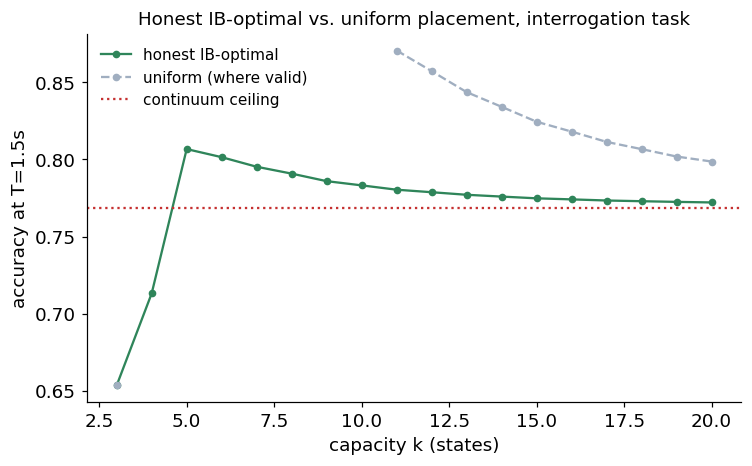

IB-optimal accuracy stays within [-0.115, +0.038] of the
true ceiling, itself showing a small version of the same overshoot-then-relax pattern documented in
03_ddm.ipynb (worst at low-mid k, negligible by k~15+). Uniform, on the k where it's even valid,
overshoots the ceiling by up to +0.102 -- not real accuracy (nothing can
exceed the true ceiling), but a much larger version of the same finite-difference reconstruction
artifact documented in 03_ddm.ipynb's discretization-artifact note: uniform's widely-spaced nodes
in low-occupancy regions accumulate more local grid error than IB-optimal's occupancy-concentrated
spacing. So "honest vs. uniform" isn't the informative comparison here the way it was for the
absorbing case (03_ddm.ipynb Part C) -- uniform's numbers, where computable at all, aren't
trustworthy enough to compare against. IB-optimal placement's accuracy is the only reliable curve.


In [6]:
k_list_acc = list(range(3, 21))
rows_interrog = []
for k in k_list_acc:
    b_opt, _, _, z0g_opt = optimal_partition_fixed_start(fr["w"], fr["q"], k, fr["z0_index"])
    b_unif, z0g_unif = uniform_partition_boundaries_fixed_start(len(fr["w"]), k, fr["z0_index"])
    xn_opt = group_centroids(fr["x"], fr["w"], b_opt)
    xn_unif = group_centroids(fr["x"], fr["w"], b_unif)
    valid_opt = is_valid_reflecting_chain(xn_opt, v0, s)
    valid_unif = is_valid_reflecting_chain(xn_unif, v0, s)
    acc_opt = interrogation_chain_stats(xn_opt, v0, s, z0g_opt, [T_max_view])[0] if valid_opt else np.nan
    acc_unif = interrogation_chain_stats(xn_unif, v0, s, z0g_unif, [T_max_view])[0] if valid_unif else np.nan
    rows_interrog.append((k, acc_opt, acc_unif))

acc_ceiling = continuous_interrogation_accuracy(v0, s, [T_max_view])[0]
fig, ax = plt.subplots(figsize=(7, 4.4))
ks_r = [r[0] for r in rows_interrog]
ax.plot(ks_r, [r[1] for r in rows_interrog], "o-", color="#2f855a", ms=4, label="honest IB-optimal")
ax.plot(ks_r, [r[2] for r in rows_interrog], "o--", color="#a0aec0", ms=4, label="uniform (where valid)")
ax.axhline(acc_ceiling, color="#c53030", ls=":", label="continuum ceiling")
ax.set_xlabel("capacity k (states)")
ax.set_ylabel(f"accuracy at T={T_max_view}s")
ax.set_title("Honest IB-optimal vs. uniform placement, interrogation task")
ax.legend(frameon=False, fontsize=10)
fig.tight_layout()
plt.show()

unif_over_ceiling = [r[2] - acc_ceiling for r in rows_interrog if not np.isnan(r[2])]
opt_over_ceiling = [r[1] - acc_ceiling for r in rows_interrog]
print(f"IB-optimal accuracy stays within [{min(opt_over_ceiling):+.3f}, {max(opt_over_ceiling):+.3f}] of the")
print(f"true ceiling, itself showing a small version of the same overshoot-then-relax pattern documented in")
print(f"03_ddm.ipynb (worst at low-mid k, negligible by k~15+). Uniform, on the k where it's even valid,")
print(f"overshoots the ceiling by up to {max(unif_over_ceiling):+.3f} -- not real accuracy (nothing can")
print(f"exceed the true ceiling), but a much larger version of the same finite-difference reconstruction")
print(f"artifact documented in 03_ddm.ipynb's discretization-artifact note: uniform's widely-spaced nodes")
print(f"in low-occupancy regions accumulate more local grid error than IB-optimal's occupancy-concentrated")
print(f"spacing. So \"honest vs. uniform\" isn't the informative comparison here the way it was for the")
print(f"absorbing case (03_ddm.ipynb Part C) -- uniform's numbers, where computable at all, aren't")
print(f"trustworthy enough to compare against. IB-optimal placement's accuracy is the only reliable curve.")

### Validation: matrix exponential vs. simulation

`state_distribution_at`'s exact matrix-exponential solution, checked against direct Gillespie-style simulation of the same reflecting chain (`simulate_reflecting_chain_path`).

In [7]:
k_val = 8
b_val, _, _, z0g_val = optimal_partition_fixed_start(fr["w"], fr["q"], k_val, fr["z0_index"])
xn_val = group_centroids(fr["x"], fr["w"], b_val)

exact_acc = interrogation_chain_stats(xn_val, v0, s, z0g_val, [T_max_view])[0]

rng_val = np.random.default_rng(5)
N_val = 60_000
signs = rng_val.choice([1, -1], size=N_val)
correct = np.empty(N_val)
for i, sign_i in enumerate(signs):
    _, xs = simulate_reflecting_chain_path(xn_val, sign_i * v0, s, z0g_val, T_max_view,
                                            seed=int(rng_val.integers(1_000_000_000)))
    xfinal = xs[-1]
    if xfinal == xn_val[z0g_val]:
        correct[i] = 0.5
    else:
        correct[i] = float((xfinal > xn_val[z0g_val]) == (sign_i == 1))

print(f"k={k_val}, T={T_max_view}: exact (matrix exponential) = {exact_acc:.4f},  "
      f"simulated ({N_val:,} trials) = {correct.mean():.4f}")

k=8, T=1.5: exact (matrix exponential) = 0.7908,  simulated (60,000 trials) = 0.7875


### Foundations summary

The interrogation task keeps the DDM's stationary-source, 1-D-accumulator structure but removes the one thing that let `03_ddm.ipynb` get away with a self-timed readout: there's no boundary crossing to key resolution off of, so occupancy has to be built from the task's actual (externally-imposed) viewing-duration distribution rather than read off a fundamental matrix, and the chain's dynamics have to reflect rather than absorb. Both changes are exact, closed-form extensions of the absorbing-case machinery, not new approximations. Two consequences carry directly into the dynamics and predictions sections below: uniform spacing can be outright numerically invalid at capacities where IB-optimal placement remains well-defined, and even where uniform spacing is technically valid its accuracy numbers are frequently not trustworthy -- they substantially overshoot the true ceiling, a much larger version of the finite-difference reconstruction artifact `03_ddm.ipynb` documents, because widely-spaced uniform nodes accumulate more local grid error in low-occupancy regions than occupancy-concentrated IB-optimal spacing does. IB-optimal placement's own accuracy stays well-behaved (converging to the true ceiling from below) throughout. Concentrating resolution where occupancy is high is therefore closer to a structural requirement than a refinement in this task -- not just for validity, but for getting a trustworthy accuracy number at all.

---

## Single-decision dynamics

The mechanics (occupancy as a mixture over viewing duration, a reflecting rather than absorbing chain, deterministic readout) are derived and validated in the Foundations section above. What follows is what that machinery produces on individual trials.

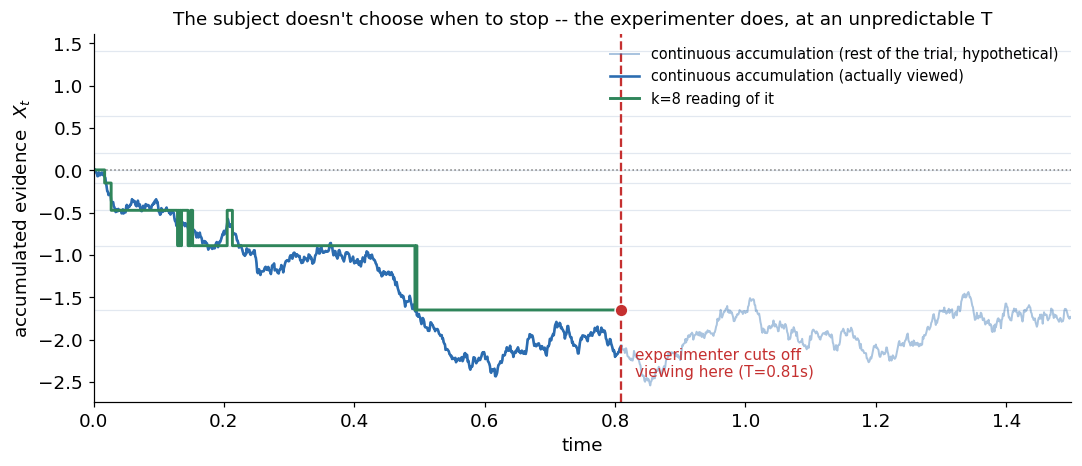

Viewing cut off at T=0.810s, drawn from the task's own near-flat-hazard distribution -- not
chosen by the accumulation process itself. The k=8 observer's reported choice is whatever state it's
in at that instant (rung at x=-1.65 here), read off the same lookup-table logic as
every ladder in this notebook -- just with no boundary to lock into first. The light grey rungs never
absorb: past the cutoff, the continuous trace (faint) keeps going, and so would the coarse reading,
if the experimenter had waited longer.


In [8]:
t0_view, tau_view, T_max_view = 0.1, 0.3, 1.5
x_range_view, k0_fine = 8.0, 1500

rng_view = np.random.default_rng(14)
T_drawn = t0_view + rng_view.exponential(tau_view)
while T_drawn > T_max_view:
    T_drawn = t0_view + rng_view.exponential(tau_view)

a_big = 12 * s * np.sqrt(T_max_view)  # >8 sigma from either edge over [0, T_max_view]: effectively unbounded
ts_free, xs_free = simulate_ddm_path(v, s, a_big, 0.5, dt=1e-3, t_max=T_max_view, seed=7)
xs_free = xs_free - 0.5 * a_big  # recenter: this task starts at 0, not at z_frac*a

k_demo_interrog = 8
r_demo = ib_optimal_chain_interrogation(k0_fine, k_demo_interrog, v, s, t0_view, tau_view,
                                         T_max_view, x_range_view, Tvals=[T_max_view])
xs_quant_demo = quantize_ddm_path(ts_free, xs_free, r_demo["x_nodes_opt"])
mask_viewed = ts_free <= T_drawn
readout_state = xs_quant_demo[mask_viewed][-1]

fig, ax = plt.subplots(figsize=(10, 4.4))
for xb in r_demo["x_nodes_opt"]:
    ax.axhline(xb, color="#e2e8f0", lw=0.8, zorder=0)
ax.axhline(0, color="gray", ls=":", lw=1)
ax.plot(ts_free, xs_free, color=NORM_COLOR, lw=1.3, alpha=0.4,
        label="continuous accumulation (rest of the trial, hypothetical)")
ax.plot(ts_free[mask_viewed], xs_free[mask_viewed], color=NORM_COLOR, lw=1.7,
        label="continuous accumulation (actually viewed)")
ax.step(ts_free[mask_viewed], xs_quant_demo[mask_viewed], color="#2f855a", lw=1.9, where="post",
        label=f"k={k_demo_interrog} reading of it")
ax.axvline(T_drawn, color="#c53030", ls="--", lw=1.5)
ax.text(T_drawn + 0.02, 0.06, f"experimenter cuts off\nviewing here (T={T_drawn:.2f}s)",
        transform=ax.get_xaxis_transform(), color="#c53030", fontsize=10, va="bottom", ha="left")
ax.scatter([T_drawn], [readout_state], color="#c53030", zorder=6, s=70, edgecolor="white")
ax.set_xlabel("time")
ax.set_ylabel("accumulated evidence  $X_t$")
ax.set_xlim(0, T_max_view)
ax.legend(frameon=False, fontsize=9.5, loc="upper right")
ax.set_title("The subject doesn't choose when to stop -- the experimenter does, at an unpredictable T")
fig.tight_layout()
plt.show()

print(f"Viewing cut off at T={T_drawn:.3f}s, drawn from the task's own near-flat-hazard distribution -- not")
print("chosen by the accumulation process itself. The k=8 observer's reported choice is whatever state it's")
print(f"in at that instant (rung at x={readout_state:.2f} here), read off the same lookup-table logic as")
print("every ladder in this notebook -- just with no boundary to lock into first. The light grey rungs never")
print("absorb: past the cutoff, the continuous trace (faint) keeps going, and so would the coarse reading,")
print("if the experimenter had waited longer.")

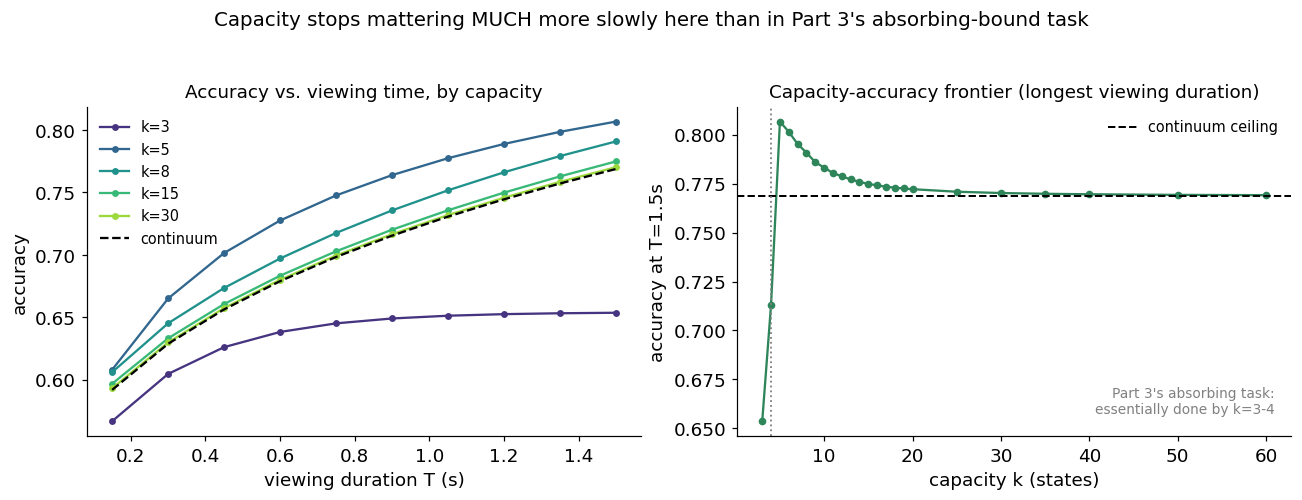

Continuum ceiling at T=1.5s: 0.7688.
Gets within 1 percentage point at k=13, within half a point at k=17 --
compare Part 3's absorbing task, already within a percent or two by k=3-4 (3.4). The same small
finite-difference reconstruction artifact documented after 3.5 shows up here too, just larger in
relative terms (k=5 reaches 0.807 against a 0.769 ceiling before
relaxing back down onto it) -- not a new effect, the same reconstruction bias at a k where the
ceiling itself is still far from reached.

7 of the 24 evenly-spaced ('uniform') placements tested are numerically
INVALID in this k range (negative jump rates -- the discretization itself breaks, not just becomes
suboptimal), at k where the IB-optimal placement stays well-defined throughout. Concentrating
resolution where occupancy is actually high isn't just more informative here -- it's close to a
requirement for the representation to make sense at all.


In [9]:
Tvals_view = np.linspace(0.15, T_max_view, 10)
acc_cont_view = continuous_interrogation_accuracy(v, s, Tvals_view)

k_curves = [3, 5, 8, 15, 30]
k_grid_view = list(range(3, 21)) + [25, 30, 35, 40, 50, 60]
results_view = {k: ib_optimal_chain_interrogation(k0_fine, k, v, s, t0_view, tau_view, T_max_view,
                                                    x_range_view, Tvals_view)
                 for k in sorted(set(k_curves) | set(k_grid_view))}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
colors_view = plt.cm.viridis(np.linspace(0.15, 0.85, len(k_curves)))
for k, col in zip(k_curves, colors_view):
    axes[0].plot(Tvals_view, results_view[k]["acc_opt"], "o-", color=col, ms=3.5, label=f"k={k}")
axes[0].plot(Tvals_view, acc_cont_view, "--", color="black", lw=1.5, label="continuum")
axes[0].set_xlabel("viewing duration T (s)")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Accuracy vs. viewing time, by capacity")
axes[0].legend(frameon=False, fontsize=9.5)

acc_at_Tmax = [results_view[k]["acc_opt"][-1] if results_view[k]["valid_opt"] else np.nan for k in k_grid_view]
axes[1].plot(k_grid_view, acc_at_Tmax, "o-", color="#2f855a", ms=4)
axes[1].axhline(acc_cont_view[-1], color="black", ls="--", lw=1.3, label="continuum ceiling")
axes[1].axvline(4, color="gray", ls=":", lw=1.2)
axes[1].text(0.97, 0.06, "Part 3's absorbing task:\nessentially done by k=3-4",
             transform=axes[1].transAxes, fontsize=9, color="gray", ha="right", va="bottom")
axes[1].set_xlabel("capacity k (states)")
axes[1].set_ylabel(f"accuracy at T={T_max_view}s")
axes[1].set_title("Capacity-accuracy frontier (longest viewing duration)")
axes[1].legend(frameon=False, fontsize=9.5)
fig.suptitle("Capacity stops mattering MUCH more slowly here than in Part 3's absorbing-bound task", y=1.03)
fig.tight_layout()
plt.show()

gap = np.abs(np.array(acc_at_Tmax) - acc_cont_view[-1])
k_within_1pct = k_grid_view[int(np.argmax(gap < 0.01))]
k_within_halfpct = k_grid_view[int(np.argmax(gap < 0.005))]
print(f"Continuum ceiling at T={T_max_view}s: {acc_cont_view[-1]:.4f}.")
print(f"Gets within 1 percentage point at k={k_within_1pct}, within half a point at k={k_within_halfpct} --")
print("compare Part 3's absorbing task, already within a percent or two by k=3-4 (3.4). The same small")
print("finite-difference reconstruction artifact documented after 3.5 shows up here too, just larger in")
i5 = k_grid_view.index(5)
print(f"relative terms (k=5 reaches {acc_at_Tmax[i5]:.3f} against a {acc_cont_view[-1]:.3f} ceiling before")
print("relaxing back down onto it) -- not a new effect, the same reconstruction bias at a k where the")
print("ceiling itself is still far from reached.")
print()
n_invalid_unif = sum(1 for k in k_grid_view if not results_view[k]["valid_unif"])
print(f"{n_invalid_unif} of the {len(k_grid_view)} evenly-spaced ('uniform') placements tested are numerically")
print("INVALID in this k range (negative jump rates -- the discretization itself breaks, not just becomes")
print("suboptimal), at k where the IB-optimal placement stays well-defined throughout. Concentrating")
print("resolution where occupancy is actually high isn't just more informative here -- it's close to a")
print("requirement for the representation to make sense at all.")

**Part 4 takeaway.** Swapping Part 3's self-timed, absorbing decision for an externally-timed, non-absorbing readout shows that the same discrete "mental model" construction can look almost exactly like the full continuous DDM in one task and look nothing like it in another, without changing anything about *how the representation itself is built* — only about what the world asks it to report, and when.

- **Capacity (`k`) still buys a ceiling that's never made worse by having more of it**, built by the same bounded, non-uniformly-spaced-chain machinery as Part 3 — but the returns now diminish *far more slowly*: roughly k=13 to get within a percentage point of the continuum, k=17 for half a point, against k=3-4 for Part 3's absorbing task. A terminating decision only ever needs two low-dimensional facts right (which side, roughly when); reading the accumulator's literal position out at an unpredictable moment asks for much more of the continuous range to actually be resolved.
- **This resolves 3.1's puzzle structurally, not just diagnostically.** 3.1's blocky, visibly-different-from-continuous single-trial readings and 3.4's "already within a percent or two by k=3-4" numbers looked like they described different worlds because they measure different things: a terminating decision's accuracy and mean RT are just two low-dimensional summaries a coarse chain can nail while still generating individual paths that look nothing like the smooth original. Remove the boundary that lets the process throw away everything except "which side, and when," and that gap between "fine in aggregate" and "faithful moment to moment" closes — because the aggregate statistic being scored (accuracy at a fixed, externally-chosen T) now *is* close to asking for the whole trajectory to be right.
- **Uniform spacing doesn't just perform worse here, it can break outright** — numerically invalid (negative jump rates), not merely suboptimal — at capacities where the IB-optimal placement stays perfectly well-defined. Concentrating resolution where occupancy is actually high isn't a refinement in this task; it's close to a requirement.

---

## Testable predictions

### Capacity requirements are task-structure-dependent, not a fixed property of "capacity limitation"

The headline finding above (roughly 3-4x the states needed to close the same ceiling-gap, compared to `03_ddm.ipynb`'s absorbing task) is itself a testable, parameter-free-in-form prediction: **the same capacity-limited observer should show very different sensitivity to capacity depending on whether the task lets it commit to a low-dimensional summary (an absorbing bound) or forces it to report something closer to the raw accumulator state (interrogation).** A single fitted capacity parameter that explains DDM behavior should predict a *worse*-than-naively-expected interrogation-task performance at the same nominal capacity, not an equally-good one — a specific, checkable cross-task consistency constraint on any capacity-fitting procedure, not just a qualitative claim.

### Open / placeholder predictions

- **A direct behavioral test** would need a task that administers both an absorbing-bound (RT) version and an interrogation (fixed/variable viewing duration) version to the same subjects with matched drift/noise, and check whether a single capacity parameter fit to one predicts performance on the other via the ratio derived above — not yet done.
- **Confidence/discreteness** (per `01_beads.ipynb`) applies here too in principle: a capacity-limited observer's confidence at the interrogation moment should be a step function of accumulator state, not graded — not yet worked out in this task's specific terms.
- **Session-level capacity fitting and neural predictions** are cross-task; see `01_beads.ipynb`'s and `03_ddm.ipynb`'s predictions sections. One interrogation-specific angle worth flagging: because this task reads out the accumulator's literal position rather than a boundary-crossing event, it is arguably the *sharpest* available test of discrete-state (vs. continuous-manifold) neural population structure among the four tasks in this series, since aggregate behavioral measures can't average away a coarse representation the way they can for the DDM (this notebook's own foundations point 2 in the takeaway above).